# Parietal DAN Patch

1. NPC mask
2. Netwotk patches --> parietal one!

In [1]:
import sys
import os.path as op
import warnings

sys.path.insert(0, '/home/ubuntu/git/parietal_patterns/nets_PFM')
from config import ATLAS_NETWORK_NAMES

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [129]:
# ── Atlas ──────────────────────────────────────────────────────────────────
ATLAS = 'caNets_DDnr'   # 'gordon17' | 'caNets_DDnr'

NETWORK_NAMES = ATLAS_NETWORK_NAMES[ATLAS]

# ── Paths ──────────────────────────────────────────────────────────────────
BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
BIDS_ORIG        = '/mnt_03/ds-dnumrisk'

PFM_ROOT         = '/mnt_03/ds-dnumrisk/derivatives/pfm_fslr'
NEUROMAPS_FSLR   = '/home/ubuntu/neuromaps-data/atlases/fsLR'
SURF_MASKS_DIR   = op.join(BIDS_ORIG, 'derivatives/surface_masks')

# ── Subjects ───────────────────────────────────────────────────────────────
SUBJECTS = list(range(1, 67))   # sub-01 … sub-65; extend as needed
SUBJECTS.remove(5)  # sub-05 has no usable data

# Group assignment
group_df = pd.read_csv(op.join(BIDS_ROOT_LARGE, 'group_assignment.csv')).set_index('subject')


In [130]:
from utils_01 import get_template_vertex_area, load_individual_vertex_areas
tpl_vertex_areas, cortex_mask_L, cortex_mask_R = get_template_vertex_area(NEUROMAPS_FSLR)
cortex_mask_both = np.concatenate([cortex_mask_L, cortex_mask_R])

from parietal_patterns.utils.surfaces import get_NPC_mask
npc_mask = get_NPC_mask(space='fslr_den-32k', hemi='both') # 64984
npc_mask_cortex = npc_mask[cortex_mask_both] # 59412

ind_areas_dict = load_individual_vertex_areas(PFM_ROOT, SUBJECTS, NEUROMAPS_FSLR) # N_subs x 59412

Valid cortical nodes: L=29696, R=29716, total=59412
Total template cortical area: 178349 mm² (1783.5 cm²)
Valid cortical nodes: L=29696, R=29716, total=59412
Total template cortical area: 178349 mm² (1783.5 cm²)
Individual areas loaded for 65 subjects


In [131]:
def network_sizes_for_subject(sub_id, method='vertex_count', ROI_mask=None):
    """Return dict {network_label: size} for one subject.
    
    method: 'vertex_count' | 'template_area' | 'individual_area'
    """
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                       f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')
    data = np.load(net_file)
    labels = data['network_labels']   # (n_valid,), may be < 59412 if some vertices had dropout

    # Align area arrays with whatever nodes survived the valid_mask in step 03
    meta = np.load(op.join(PFM_ROOT, sub_str, 'cm',
                            f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz'))
    valid_mask = meta['valid_mask']   # (59412,) bool

    if method == 'vertex_count':
        weights = np.ones(len(labels))
    elif method == 'template_area':
        weights = tpl_vertex_areas[valid_mask]
    elif method == 'individual_area':
        weights = ind_areas_dict[sub_id][valid_mask]

    if ROI_mask is not None:
        weights = weights[ROI_mask[valid_mask]]
        labels = labels[ROI_mask[valid_mask]]

    unique_labels = np.unique(labels)
    return {lbl: weights[labels == lbl].sum() for lbl in unique_labels}

In [132]:
methods = ['vertex_count', 'template_area', 'individual_area']
results = {m: {} for m in methods}

from tqdm.auto import tqdm
for sub_id in tqdm(SUBJECTS, desc='subjects'):
    for m in methods:
        r = network_sizes_for_subject(sub_id, method=m, ROI_mask=npc_mask_cortex)
        if r is not None:
            results[m][sub_id] = r

print('Done. Subjects per method:', {m: len(results[m]) for m in methods})

subjects: 100%|██████████| 65/65 [00:00<00:00, 393.85it/s]

Done. Subjects per method: {'vertex_count': 65, 'template_area': 65, 'individual_area': 65}


In [133]:
def to_dataframe(results_dict, method_name, group_df):
    """Convert results dict to long-form DataFrame."""
    rows = []
    for sub_id, sizes in results_dict.items():
        for lbl, size in sizes.items():
            if lbl == 0:   # skip unassigned
                continue
            rows.append({
                'subject': sub_id,
                'group': group_df.loc[sub_id, 'group'] if sub_id in group_df.index else np.nan,
                'network_id': lbl,
                'network': NETWORK_NAMES.get(lbl, f'Net-{lbl}'),
                'size': size,
                'method': method_name,
            })
    return pd.DataFrame(rows)


dfs = [to_dataframe(results[m], m, group_df) for m in methods]
df_all = pd.concat(dfs, ignore_index=True)

# Convert areas to cm² for readability
df_all.loc[df_all['method'] != 'vertex_count', 'size'] /= 100

print(df_all.head(10))
print(f'Shape: {df_all.shape}')

   subject  group  network_id            network     size        method
0        1      0           2            Visual2   76.000  vertex_count
1        1      0           3        Somatomotor  332.000  vertex_count
2        1      0           4  Cingulo-Opercular   82.000  vertex_count
3        1      0           5   Dorsal-attention 3206.000  vertex_count
4        1      0           7     Frontoparietal   67.000  vertex_count
5        1      0           9            Default  256.000  vertex_count
6        2      1           2            Visual2  928.000  vertex_count
7        2      1           3        Somatomotor  790.000  vertex_count
8        2      1           4  Cingulo-Opercular   47.000  vertex_count
9        2      1           5   Dorsal-attention 2160.000  vertex_count
Shape: (1089, 6)


In [134]:
measure_method = 'individual_area'
df_spec = df_all[df_all['method'] == measure_method].copy()

networks = sorted(df_all['network'].unique())


In [ ]:
    # T-test
    g0 = net_df[net_df['group'] == 0]['size'].values
    g1 = net_df[net_df['group'] == 1]['size'].values
    if len(g0) > 1 and len(g1) > 1:
        t, p = stats.ttest_ind(g0, g1)
        axes[i].set_title(f'{net}\nt={t:.2f}, p={p:.3f}', fontsize=15)
    else:
        axes[i].set_title(net, fontsize=10)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)


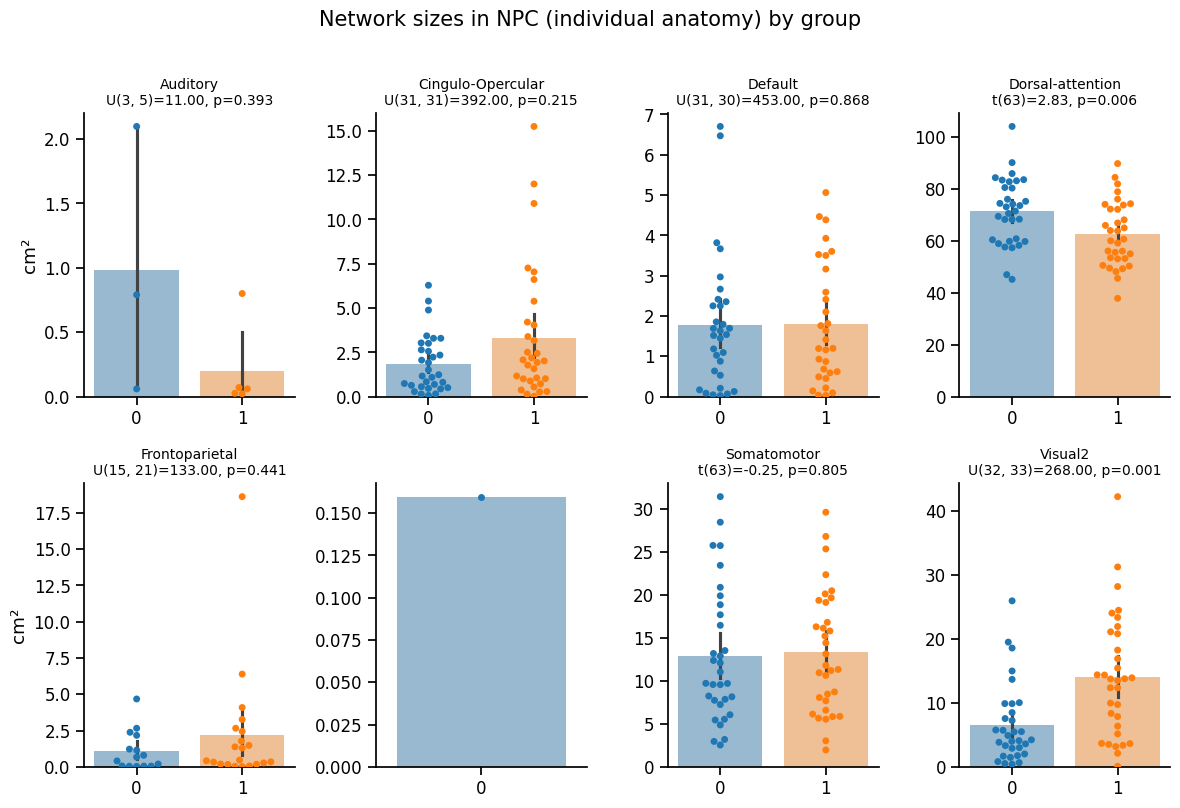

In [139]:
from parietal_patterns.utils.statistics import between_group_comparison

sns.set_context('notebook', font_scale=1.1)

n_nets = len(networks)
ncols = 4
nrows = int(np.ceil(n_nets / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 4))
axes = axes.flatten()

palette = {str(0): '#4C72B0', str(1): '#DD8452'}

for i, net in enumerate(networks):
    net_df = df_spec[df_spec['network'] == net]
    sns.barplot(data=net_df, x='group', hue='group', y='size', alpha=0.5, legend=False, ax=axes[i])
    sns.swarmplot(data=net_df, x='group', hue='group', y='size', size=5, legend=False, ax=axes[i])

    try: 
        stats, test = t, p = between_group_comparison(net_df, 'size', group_names = [0,1])
        axes[i].set_title(f'{net}\n{test}={stats.statistic:.2f}, p={stats.pvalue:.3f}', fontsize = 10)
    except: 
        None
    axes[i].set_xlabel(''); axes[i].set_ylabel('cm²' if i % ncols == 0 else '')
    sns.despine()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Network sizes in NPC (individual anatomy) by group', y=1.01, fontsize=15)
plt.tight_layout(); plt.show()


In [140]:
# Summary statistics table + uncorrected t-tests
from scipy import stats

rows = []
for net in networks:
    sub_data = df_spec[df_spec['network'] == net]
    g0 = sub_data[sub_data['group'] == 0]['size'].values
    g1 = sub_data[sub_data['group'] == 1]['size'].values
    t, p = stats.ttest_ind(g0, g1) if (len(g0) > 1 and len(g1) > 1) else (np.nan, np.nan)
    rows.append({
        'network': net,
        'group0_mean': np.round(g0.mean(), 3),
        'group0_std':  np.round(g0.std(), 3),
        'group1_mean': np.round(g1.mean(), 3),
        'group1_std':  np.round(g1.std(), 3),
        't': np.round(t, 3), 'p_uncorrected':np.round(p, 4),
    })

stats_df = (pd.DataFrame(rows)
            .sort_values('p_uncorrected')
            .reset_index(drop=True))

# Bonferroni correction
n_tests = stats_df['p_uncorrected'].notna().sum()
stats_df['p_bonferroni'] = (stats_df['p_uncorrected'] * n_tests).clip(upper=1.0)

pd.set_option('display.float_format', '{:.3f}'.format)
display(stats_df)

/tmp/ipykernel_654519/2805055428.py:14: RuntimeWarning: Mean of empty slice.
  'group1_mean': np.round(g1.mean(), 3),
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,network,group0_mean,group0_std,group1_mean,group1_std,t,p_uncorrected,p_bonferroni
0,Visual2,6.591,6.016,14.017,9.393,-3.724,0.000,0.003
1,Dorsal-attention,71.484,12.652,62.608,12.217,2.833,0.006,0.043
2,Cingulo-Opercular,1.861,1.596,3.330,3.696,-1.999,0.050,0.351
3,Auditory,0.982,0.843,0.196,0.303,1.639,0.152,1.000
4,Frontoparietal,1.102,1.294,2.182,4.007,-0.979,0.335,1.000
5,Somatomotor,12.885,7.727,13.345,6.994,-0.248,0.805,1.000
6,Default,1.768,1.630,1.802,1.484,-0.084,0.933,1.000
7,Posterior-Multimodal,0.160,0.000,NaN,NaN,NaN,NaN,NaN


In [13]:
sub_id = 4
sub_str = f'sub-{sub_id:02d}'
method = 'individual_area'

net_file = op.join(PFM_ROOT, sub_str, 'networks',
                    f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')

data = np.load(net_file)
labels = data['network_labels']   # (n_valid,), may be < 59412 if some vertices had dropout

# Align area arrays with whatever nodes survived the valid_mask in step 03
meta = np.load(op.join(PFM_ROOT, sub_str, 'cm',
                        f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz'))
valid_mask = meta['valid_mask']   # (59412,) bool


In [14]:
surf_map = np.zeros_like(cortex_mask_both, dtype=int)
combined_maks = np.zeros(len(cortex_mask_both), dtype=bool)
combined_maks[cortex_mask_both] = valid_mask
surf_map[combined_maks] = labels

surf_map_R = surf_map[len(cortex_mask_L):]  # right hemisphere part of the surface map
npc_mask_R = npc_mask[len(cortex_mask_L):]

surf_map_R[npc_mask_R == False] = 0

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


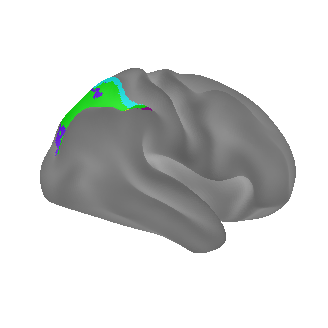

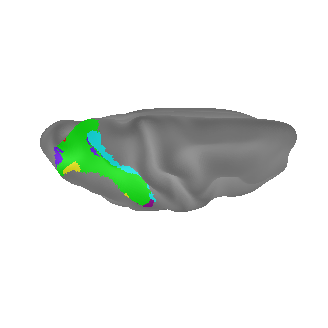

In [15]:
from nilearn import plotting
from utils_01 import get_CANets_cmap

cmap_atlas = get_CANets_cmap()

from neuromaps.datasets import fetch_atlas
fslr = fetch_atlas('fsLR', '32k') 
# nib.load(fslr['inflated'].R).agg_data()[0].shape == 32492
fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, figsize=(4,4))
plotting.plot_surf(
    str(fslr['inflated'].R),
    surf_map_R,
    hemi='right',
    view='lateral',
    cmap=cmap_atlas,         # discrete colormap, up to 20 networks
    vmin=0, 
    vmax=12, #if ref_name == 'caNets_DDnr' else 17, # adjust vmax based on the number of networks in the atlas
    avg_method = 'median',
    darkness=1.0,
    colorbar=False,
    bg_map= str(fslr['sulc'].R),
    bg_on_data=True,
    axes=ax
    )
plt.show()

fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, figsize=(4,4))
plotting.plot_surf(
    str(fslr['inflated'].R),
    surf_map_R,
    hemi='right',
    view='dorsal',
    cmap=cmap_atlas,         # discrete colormap, up to 20 networks
    vmin=0, 
    vmax=12, #if ref_name == 'caNets_DDnr' else 17, # adjust vmax based on the number of networks in the atlas
    avg_method = 'median',
    darkness=1.0,
    colorbar=False,
    bg_map= str(fslr['sulc'].R),
    bg_on_data=True,
    axes=ax
    )
plt.show()

In [16]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

def get_surface_patches(surf_map, surface_gifti_path, target_label):
    """
    Find spatially contiguous patches of a network label on the surface.
    
    surf_map : (n_verts,) int array — network label per vertex (0 = unassigned)
    surface_gifti_path : path to .surf.gii (midthickness or inflated)
    target_label : int — network label to split into patches
    
    Returns: list of vertex index arrays, one per patch, sorted largest first
    """
    surf = nib.load(surface_gifti_path)
    faces = surf.darrays[1].data          # (n_faces, 3)
    n_verts = surf.darrays[0].data.shape[0]

    # Build sparse adjacency from triangle edges
    i = np.concatenate([faces[:,0], faces[:,1], faces[:,2]])
    j = np.concatenate([faces[:,1], faces[:,2], faces[:,0]])
    adj = csr_matrix((np.ones(len(i)), (i, j)), shape=(n_verts, n_verts))

    # Vertices belonging to the target network
    net_verts = np.where(surf_map == target_label)[0]

    # Subgraph adjacency among those vertices only
    sub_adj = adj[net_verts][:, net_verts]

    n_comp, comp_labels = connected_components(sub_adj, directed=False)

    patches = [net_verts[comp_labels == c] for c in range(n_comp)]
    patches.sort(key=len, reverse=True)   # largest patch first
    return patches


In [17]:
# surf_map_R is your (32492,) label vector for the right hemisphere

surf_map_R = surf_map[len(cortex_mask_L):]

patches = get_surface_patches(
    surf_map_R,
    str(fslr['midthickness'].R),   # or 'inflated'
    target_label=5
)

print(f"{len(patches)} patches found")
for i, p in enumerate(patches):
    print(f"  Patch {i}: {len(p)} vertices")

# The parietal patch is typically the largest — patches[0]
parietal_patch_verts = patches[0]


3 patches found
  Patch 0: 1642 vertices
  Patch 1: 3 vertices
  Patch 2: 1 vertices


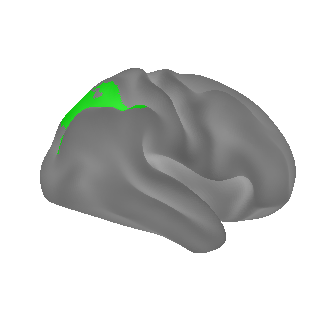

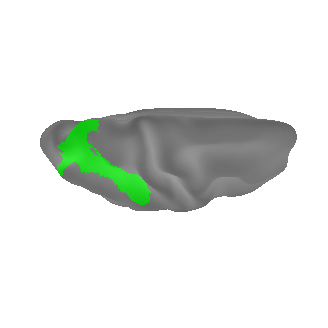

In [141]:
patch_map_R = np.zeros(len(surf_map_R), dtype=int)
patch_map_R[parietal_patch_verts] = 5   # keep the original label value

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(4, 4))
plotting.plot_surf(
    str(fslr['inflated'].R),
    patch_map_R,
    hemi='right',
    view='lateral',
    cmap=cmap_atlas,
    vmin=0, vmax=12,
    avg_method='median',
    darkness=1.0,
    colorbar=False,
    bg_map=str(fslr['sulc'].R),
    bg_on_data=True,
    axes=ax
)
plt.show()

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(4, 4))
plotting.plot_surf(
    str(fslr['inflated'].R),
    patch_map_R,
    hemi='right',
    view='dorsal',
    cmap=cmap_atlas,
    vmin=0, vmax=12,
    avg_method='median',
    darkness=1.0,
    colorbar=False,
    bg_map=str(fslr['sulc'].R),
    bg_on_data=True,
    axes=ax
)
plt.show()

### Patch size comparison between groups

1. build adjaceny matrix from standard fsLR surface
2. build mean centroid positions for all patches from reference (group average CA-magjudge network map)
3. 

In [19]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import cdist

# ── Precompute adjacency once (shared across subjects) ─────────────────────
def build_adj_and_coords(surf_path):
    surf = nib.load(surf_path)
    coords = surf.darrays[0].data          # (32492, 3)
    faces  = surf.darrays[1].data          # (n_faces, 3)
    n = coords.shape[0]
    i = np.concatenate([faces[:,0], faces[:,1], faces[:,2]])
    j = np.concatenate([faces[:,1], faces[:,2], faces[:,0]])
    adj = csr_matrix((np.ones(len(i)), (i, j)), shape=(n, n))
    return adj, coords

adj_L, coords_L = build_adj_and_coords(str(fslr['midthickness'].L))
adj_R, coords_R = build_adj_and_coords(str(fslr['midthickness'].R))


In [21]:
# ── Build reference centroids from the group-average atlas ────────────────
atlas_path = op.join(PFM_ROOT, 'atlases',
                     f'caNets_DDnr-magjudge-task-average-from-fsav5_space-fsLR_den-32k_cortex.npz')

atlas_labels = np.load(atlas_path)['labels']   # (64984,)
atlas_map_L  = atlas_labels[:32492]            # full L hemi, medial wall = 0
atlas_map_R  = atlas_labels[32492:]            # full R hemi, medial wall = 0

atlas_ref_patches = []
for hemi, adj, coords, hemi_map in [
    ('L', adj_L, coords_L, atlas_map_L),
    ('R', adj_R, coords_R, atlas_map_R),
]:
    net_verts = np.where(hemi_map == 5)[0]
    sub_adj   = adj[net_verts][:, net_verts]
    n_comp, comp_labels = connected_components(sub_adj, directed=False)

    for c in range(n_comp):
        verts    = net_verts[comp_labels == c]
        centroid = coords[verts].mean(axis=0)
        atlas_ref_patches.append({
            'ref_patch': f"{hemi}_patch{c}",
            'hemi':      hemi,
            'n_verts':   len(verts),
            'centroid':  centroid,
        })


# Inspect what the atlas gives you — name them if you recognise the anatomy
ref_df = pd.DataFrame(atlas_ref_patches).drop(columns='centroid')
print(ref_df.sort_values(['hemi', 'n_verts'], ascending=[True, False]))


   ref_patch hemi  n_verts
2   L_patch2    L     2041
0   L_patch0    L     1524
4   L_patch4    L      350
1   L_patch1    L      154
3   L_patch3    L       20
5   L_patch5    L       17
6   L_patch6    L        6
7   L_patch7    L        2
11  R_patch3    R     2145
8   R_patch0    R     1654
13  R_patch5    R      290
9   R_patch1    R      157
12  R_patch4    R       72
15  R_patch7    R       33
16  R_patch8    R       10
10  R_patch2    R        3
14  R_patch6    R        3
17  R_patch9    R        3


In [76]:
sub_id = 4
sub_str = f'sub-{sub_id:02d}'
net_file = op.join(PFM_ROOT, sub_str, 'networks',
                    f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')
meta_file = op.join(PFM_ROOT, sub_str, 'cm',
                    f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz')

#surface information
areas = []
for hemi in ['L','R']:
    ind_area_file = op.join(PFM_ROOT, sub_str, 'anat',
                    f'{sub_str}_ses-1_hemi-{hemi}_vertex_areas_fsLR32k.shape.gii')
    areas.append(nib.load(ind_area_file).darrays[0].data)  # (32492,)
areas = np.concatenate(areas)[cortex_mask_both]

labels     = np.load(net_file)['network_labels']
valid_mask = np.load(meta_file)['valid_mask']

# Reconstruct cortex-space label map (59412)
surf_map_cortex = np.zeros(cortex_mask_both.sum(), dtype=int)
surf_map_cortex[valid_mask] = labels



In [79]:
target_label = 5

In [ ]:
patches = []
for hemi, adj, coords, cort_mask, cort_labels in [
    ('L', adj_L, coords_L, cortex_mask_L, surf_map_cortex[:n_L]),
    ('R', adj_R, coords_R, cortex_mask_R, surf_map_cortex[n_L:]),
    ]:

In [ ]:
net_verts

(4230,)

In [101]:
n_L = cortex_mask_L.sum()

hemi = 'L'
coords = coords_L
cort_mask = cortex_mask_L
cort_labels = surf_map_cortex[:n_L]
adj = adj_L

# Expand back to full 32492-vertex space
hemi_map = np.zeros(coords.shape[0], dtype=int)
hemi_map[cort_mask] = cort_labels

ind_area_file = op.join(PFM_ROOT, sub_str, 'anat',
                f'{sub_str}_ses-1_hemi-{hemi}_vertex_areas_fsLR32k.shape.gii')
area_hemi = nib.load(ind_area_file).darrays[0].data

net_verts = np.where(hemi_map == target_label)[0] # indices of vertices belonging to DAN
net_verts_areas = areas[net_verts]


In [ ]:
# ── Per-subject: find all DAN patches ─────────────────────────────────────
def get_dan_patches(sub_id, target_label=5):
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                       f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')
    meta_file = op.join(PFM_ROOT, sub_str, 'cm',
                        f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz')
    
    #surface information
    areas = []
    for hemi in ['L','R']:
        ind_area_file = op.join(PFM_ROOT, sub_str, 'anat',
                        f'{sub_str}_ses-1_hemi-{hemi}_vertex_areas_fsLR32k.shape.gii')
        areas.append(nib.load(ind_area_file).darrays[0].data)  # (32492,)
    areas = np.concatenate(areas)  

    labels     = np.load(net_file)['network_labels']
    valid_mask = np.load(meta_file)['valid_mask']

    # Reconstruct cortex-space label map (59412)
    surf_map_cortex = np.zeros(cortex_mask_both.sum(), dtype=int)
    surf_map_cortex[valid_mask] = labels

    n_L = cortex_mask_L.sum()
    patches = []
    for hemi, adj, coords, cort_mask, cort_labels in [
        ('L', adj_L, coords_L, cortex_mask_L, surf_map_cortex[:n_L]),
        ('R', adj_R, coords_R, cortex_mask_R, surf_map_cortex[n_L:]),
        ]:
        # Expand back to full 32492-vertex space
        hemi_map = np.zeros(coords.shape[0], dtype=int)
        hemi_map[cort_mask] = cort_labels

        # individual area
        ind_area_file = op.join(PFM_ROOT, sub_str, 'anat',
                        f'{sub_str}_ses-1_hemi-{hemi}_vertex_areas_fsLR32k.shape.gii')
        area_hemi = nib.load(ind_area_file).darrays[0].data

        net_verts = np.where(hemi_map == target_label)[0] # indices of vertices belonging to DAN
        sub_adj = adj[net_verts][:, net_verts] # adjacency information on all vetices in DAN (N_vert_net x N_vert_net)
        n_comp, comp_labels = connected_components(sub_adj, directed=False)

        for c in range(n_comp):
            verts    = net_verts[comp_labels == c] # indices of vertices belong to that patch
            centroid = coords[verts].mean(axis=0)
            patches.append({
                'sub_id':   sub_id,
                'hemi':     hemi,
                'n_verts':  len(verts),
                'ind_area_size': area_hemi[verts].sum(),
                'centroid': centroid,
            })
    return patches

# ── Collect all subjects ───────────────────────────────────────────────────
all_patches = []
for sub_id in tqdm(SUBJECTS):
    all_patches.extend(get_dan_patches(sub_id))


100%|██████████| 65/65 [00:00<00:00, 83.57it/s]


In [108]:
ref_centroids = {p['ref_patch']: p['centroid'] for p in atlas_ref_patches}

patch_rows = []
for p in all_patches:
    # Only compare within the same hemisphere
    candidates = {k: v for k, v in ref_centroids.items() if k.startswith(p['hemi'])}
    names = list(candidates.keys())
    dists = cdist([p['centroid']], [candidates[n] for n in names])[0]
    best  = names[np.argmin(dists)]

    patch_rows.append({
        'sub_id':    p['sub_id'],
        'group':     group_df.loc[p['sub_id'], 'group'] if p['sub_id'] in group_df.index else np.nan,
        'hemi':      p['hemi'],
        'ref_patch': best,
        'patch': best,
        'dist_mm':   dists.min(),    # sanity check: large dist = patch absent in atlas
        'n_verts':   p['n_verts'],
        'ind_area': p['ind_area_size']
    })

df_patches = pd.DataFrame(patch_rows)

# Flag suspicious matches (subject has a patch far from any reference patch)
print(df_patches.groupby('ref_patch')['dist_mm'].describe())


            count   mean    std   min    25%    50%    75%    max
ref_patch                                                        
L_patch0  386.000 24.128  9.905 1.182 16.921 22.900 30.126 48.062
L_patch1  330.000 18.351  8.291 0.376 13.818 18.034 23.687 44.666
L_patch2  356.000 25.898 12.300 1.223 20.766 28.685 34.078 59.150
L_patch3  367.000 19.710  9.774 0.667 12.846 21.550 26.332 45.644
L_patch4  471.000 19.735  9.847 1.169 12.799 19.001 26.971 56.421
L_patch5  246.000 14.227  7.176 0.500  8.482 14.768 18.266 33.617
L_patch6  256.000 20.255 10.586 2.067 10.689 19.215 29.035 45.001
L_patch7  241.000 16.695  7.242 3.317 10.848 15.805 21.823 32.733
R_patch0  244.000 22.594 11.173 1.309 13.087 21.823 32.783 42.848
R_patch1  185.000 14.687  6.926 0.939 10.501 15.131 19.822 31.598
R_patch2  111.000 18.394 11.868 1.004  8.423 16.301 30.431 42.635
R_patch3  448.000 25.808 10.870 0.705 22.581 28.425 33.211 44.534
R_patch4  254.000 16.281 10.451 0.865  7.216 13.512 26.589 43.465
R_patch5  

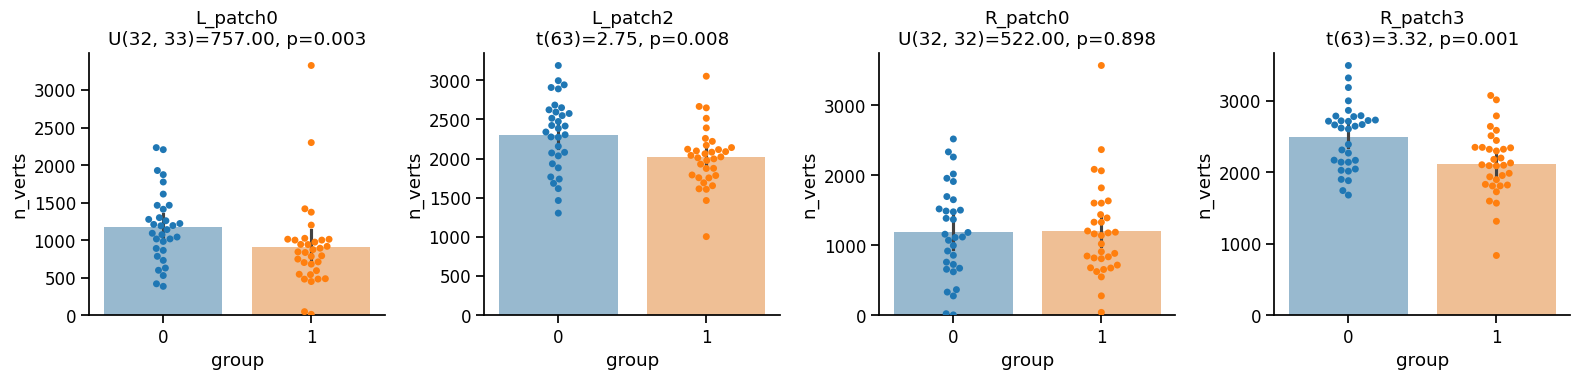

In [127]:
# only 4 largest patches
# per subject multiple patches assigned to one reference patch..... 
# take sum or select largest? --> currently sum!
from parietal_patterns.utils.statistics import between_group_comparison

top_patches = pd.DataFrame(atlas_ref_patches).drop(columns='centroid').sort_values('n_verts', ascending=False).reset_index()['ref_patch'].values[:4]
df_top_patches = df_patches[df_patches['ref_patch'].isin(top_patches)]

y_var = 'n_verts' # 'ind_area'# 

fig, axes = plt.subplots(1, df_top_patches['patch'].nunique(), figsize=(4 * df_top_patches['patch'].nunique(), 4))
for ax, patch in zip(axes, sorted(df_top_patches['patch'].unique())):
    sub = df_top_patches[df_top_patches['patch'] == patch]

    sub = pd.DataFrame(sub.groupby(['sub_id', 'group'])[y_var].sum()).reset_index()
    sns.barplot(data=sub, x='group', hue='group', y=y_var, alpha=0.5, legend=False, ax=ax)
    sns.swarmplot(data=sub, x='group', hue='group', y=y_var, size=5, legend=False, ax=ax)

    stats, test = t, p = between_group_comparison(sub, y_var, group_names = [0,1])
    ax.set_title(f'{patch}\n{test}={stats.statistic:.2f}, p={stats.pvalue:.3f}')
    sns.despine()
plt.tight_layout(); plt.show()


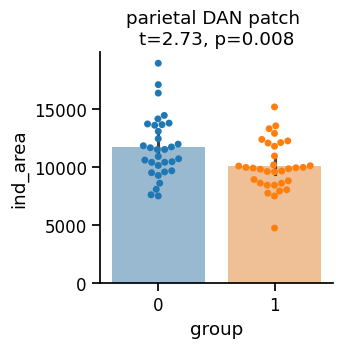

In [142]:
y_var = 'ind_area'# 'n_verts' # 

parietal_patch_L = df_top_patches[df_top_patches['patch'] == 'L_patch2'].groupby(['sub_id', 'group'])[y_var].sum()
parietal_patch_R = df_top_patches[df_top_patches['patch'] == 'R_patch3'].groupby(['sub_id', 'group'])[y_var].sum()

# parietal_patch_both
sub = pd.DataFrame(parietal_patch_L + parietal_patch_R).reset_index()

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.barplot(data=sub, x='group', hue='group', y=y_var, alpha=0.5, legend=False, ax=ax)
sns.swarmplot(data=sub, x='group', hue='group', y=y_var, size=5, legend=False, ax=ax)

g0 = sub[sub['group'] == 0][y_var].values
g1 = sub[sub['group'] == 1][y_var].values
t, p = stats.ttest_ind(g0, g1)
ax.set_title(f'parietal DAN patch \nt={t:.2f}, p={p:.3f}')
sns.despine()

In [119]:
from parietal_patterns.utils.statistics import between_group_comparison

stats, p = between_group_comparison(sub, y_var, group_names = [0,1])

In [116]:
t

TtestResult(statistic=3.324266517473119, pvalue=0.0014807590521090687, df=63.0)

In [124]:
stats.statistic

3.324266517473119